# EXAMEN 2 — Fundamentos de Data Science
## Análisis de Ventas de Videojuegos 2024 — **SOLUCIÓN**

---

**Dataset:** Ventas globales de videojuegos 2024 — títulos, plataformas, géneros, publisher y ventas por región.

> Este notebook contiene la solución de referencia del Examen 2.

---
## Configuración inicial

In [1]:
pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install kagglehub


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/video-game-sales-2024")

print("Path to dataset files:", path)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/jeedorsa/.cache/kagglehub/datasets/asaniczka/video-game-sales-2024/versions/1


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style='whitegrid')

# Reemplazar con la URL o ruta del dataset del examen
df = pd.read_csv('/Users/jeedorsa/.cache/kagglehub/datasets/asaniczka/video-game-sales-2024/versions/1/vgchartz-2024.csv')

print(f'Dataset cargado correctamente — shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')

Dataset cargado correctamente — shape: (64016, 14)
Columnas: ['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update']


---
## 1. Exploración inicial

In [5]:
# Primeras y últimas filas
display(df.head())
display(df.tail())

# Tipos de datos y valores no nulos
df.info()

# Estadísticas descriptivas iniciales (antes de limpiar)
display(df.describe())

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24
64015,/games/boxart/default.jpg,Yurukill: The Calumniation Games,PS4,Visual Novel,Unknown,G.rev Ltd.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-09-29


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


**Observaciones iniciales:**

- El dataset contiene 64,016 registros de videojuegos con 14 columnas: variables numéricas (ventas por región, puntuación de críticos) y categóricas (género, consola, publisher).
- La columna `img` contiene URLs de imágenes — no aporta valor analítico y la eliminaremos.
- `release_date` es un string con formato `YYYY-MM-DD` — extraeremos el año para análisis temporales.
- `critic_score` ya es `float64` en este dataset (escala 0–10), pero solo tiene datos para ~6,678 juegos (~10%).
- Se observan valores nulos masivos en ventas (solo ~18,922 de 64,016 tienen `total_sales`) — muchos juegos no tienen ventas registradas.
- No hay columna de puntuación de usuarios en este dataset.

---
## 2. Limpieza de datos

### 2.1 Detección y eliminación de duplicados

In [6]:
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {n_duplicados}')

# Mostrar las filas duplicadas si existen
if n_duplicados > 0:
    print('\nEjemplos de filas duplicadas:')
    display(df[df.duplicated(keep=False)].head(10))

shape_antes = df.shape
df = df.drop_duplicates().reset_index(drop=True)
shape_despues = df.shape

print(f'\nShape antes:   {shape_antes}')
print(f'Shape después: {shape_despues}')
print(f'Filas eliminadas: {shape_antes[0] - shape_despues[0]}')

Filas duplicadas encontradas: 0

Shape antes:   (64016, 14)
Shape después: (64016, 14)
Filas eliminadas: 0


**Observación:** Es buena práctica verificar duplicados siempre como primer paso de limpieza. En este dataset podemos encontrar el mismo juego registrado con ligeras variaciones — por ejemplo, el mismo título en la misma plataforma con datos de ventas idénticos. `drop_duplicates()` elimina las filas exactamente iguales; si el juego aparece con valores distintos (por ejemplo, ventas actualizadas), eso requiere análisis adicional.

### 2.2 Verificación y ajuste de tipos de datos

In [7]:
print('Tipos ANTES de corregir:')
print(df.dtypes)
print()

# Eliminar columna img (URLs sin valor analítico)
df = df.drop(columns=['img'])
print("Columna 'img' eliminada.")

# Extraer año desde release_date (formato 'YYYY-MM-DD')
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
print(f"Columna 'year' extraída desde release_date — NaN: {df['year'].isnull().sum()}")

# critic_score ya es float64 — solo verificamos el rango
print(f"\ncritic_score — rango: [{df['critic_score'].min()}, {df['critic_score'].max()}] (escala 0–10)")

print('\nTipos DESPUÉS de corregir:')
print(df.dtypes)

Tipos ANTES de corregir:
img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object

Columna 'img' eliminada.
Columna 'year' extraída desde release_date — NaN: 7051

critic_score — rango: [1.0, 10.0] (escala 0–10)

Tipos DESPUÉS de corregir:
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
year            float64
dtype: object


**Observación:**

- La columna `img` es pura metadata de la web de scraping — no contiene información útil para análisis.
- `release_date` como string no nos permite operar temporalmente. Con `pd.to_datetime(...).dt.year` extraemos el año como entero, lo que nos permitirá agrupar y trazar tendencias históricas.
- `critic_score` ya estaba en `float64` — escala de 0 a 10 (no 0–100 como en otros datasets de videojuegos). Importante tenerlo en cuenta al definir rangos de calidad.

### 2.3 Consistencia en valores categóricos

In [8]:
# Las columnas categóricas en este dataset son todas en minúscula
for col in ['genre', 'publisher', 'console', 'developer']:
    if col in df.columns:
        print(f'\n{col} — {df[col].nunique()} valores únicos:')
        print(sorted(df[col].dropna().unique())[:15])


genre — 20 valores únicos:
['Action', 'Action-Adventure', 'Adventure', 'Board Game', 'Education', 'Fighting', 'MMO', 'Misc', 'Music', 'Party', 'Platform', 'Puzzle', 'Racing', 'Role-Playing', 'Sandbox']

publisher — 3383 valores únicos:
['100 Gates', '10TACLE Studios', '10tons', '10tons Ltd', '11 bit studios', '1337 Game Design', '13cm', '14 Degrees East', '17-Bit', '1C Company', '1C Entertainment', '1C Maddox Games', '1DER Entertainment', '1st Playable', '20th Century Fox Video Games']

console — 81 valores únicos:
['2600', '3DO', '3DS', '5200', '7800', 'ACPC', 'AJ', 'AST', 'Aco', 'All', 'Amig', 'And', 'ApII', 'Arc', 'BBCM']

developer — 8862 valores únicos:
['.theprodukkt', '07th Expansion', '0verflow', '100 Stones Interactive', '1047 Games', '10Tacle Studios Belgium', '10tacle Studios AG', '10th Art Studio', '10tons Ltd', '11 bit studios', '12 Hit Combo', '13AM Games', '13cm', '14 Degrees East', '17-Bit']


In [9]:
# Normalizar texto: quitar espacios y unificar capitalización
for col in ['genre', 'publisher', 'console', 'developer']:
    if col in df.columns:
        df[col] = df[col].str.strip().str.title()

# Correcciones puntuales de publishers con nombres inconsistentes
reemplazos_publisher = {
    'Ea': 'Electronic Arts',
    'Ea Sports': 'Electronic Arts',
    'Activision Blizzard': 'Activision',
    'Square': 'Square Enix',
    'Squaresoft': 'Square Enix',
}
df['publisher'] = df['publisher'].replace(reemplazos_publisher)

# Correcciones puntuales de géneros
reemplazos_genre = {
    'Action-Adventure': 'Action',
    'Shoot Em Up': 'Shooter',
}
df['genre'] = df['genre'].replace(reemplazos_genre)

print('Categorías después de normalizar:')
for col in ['genre', 'publisher', 'console']:
    print(f'\n{col}: {df[col].nunique()} valores únicos')

Categorías después de normalizar:

genre: 19 valores únicos

publisher: 3379 valores únicos

console: 81 valores únicos


**Observación:**

- La normalización con `.str.strip().str.title()` es el primer paso para detectar inconsistencias: `'action'`, `'Action'` y `'ACTION'` quedan todos como `'Action'`.
- Los reemplazos puntuales corrigen los casos que la normalización automática no puede resolver, como abreviaciones (`'EA'` → `'Electronic Arts'`) o sinónimos de géneros.
- Después de limpiar, el número de categorías únicas disminuye, lo que indica que había inconsistencias que se corrigieron.

### 2.4 Manejo de valores faltantes

In [10]:
# Diagnóstico completo de nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': nulos_pct
}).query('Nulos > 0').sort_values('Porcentaje (%)', ascending=False)

print('Columnas con valores faltantes:')
display(resumen_nulos)

Columnas con valores faltantes:


,Nulos,Porcentaje (%)
critic_score,57338,89.57
jp_sales,57290,89.49
na_sales,51379,80.26
pal_sales,51192,79.97
other_sales,48888,76.37
last_update,46137,72.07
total_sales,45094,70.44
release_date,7051,11.01
year,7051,11.01
developer,17,0.03


In [11]:
# Estrategia de imputación por tipo de columna

# Variables numéricas de ventas: rellenar con 0
# Justificación: ventas faltantes → juego sin datos de distribución → 0 es el marcador correcto
cols_ventas = [c for c in df.columns if 'sales' in c]
for col in cols_ventas:
    df[col] = df[col].fillna(0)
print(f'Ventas rellenadas con 0: {cols_ventas}')

# critic_score: rellenar con la mediana
# Justificación: distribución asimétrica; mediana más robusta ante valores extremos
mediana_cs = df['critic_score'].median()
df['critic_score'] = df['critic_score'].fillna(mediana_cs)
print(f'critic_score → rellenado con mediana: {mediana_cs:.2f}')

# year: rellenar con la moda
# Justificación: no podemos estimar el año de lanzamiento de otra forma
moda_year = int(df['year'].mode()[0])
df['year'] = df['year'].fillna(moda_year).astype(int)
print(f'year → rellenado con moda: {moda_year}')

# Variables categóricas: rellenar con 'Unknown'
for col in ['publisher', 'genre', 'developer']:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Unknown')
        print(f'{col} → rellenado con "Unknown"')

print(f'\nNulos totales restantes: {df.isnull().sum().sum()}')
print(f'(release_date y last_update se mantienen como referencia, no se usan en el análisis)')

Ventas rellenadas con 0: ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
critic_score → rellenado con mediana: 7.50
year → rellenado con moda: 2009
developer → rellenado con "Unknown"

Nulos totales restantes: 53188
(release_date y last_update se mantienen como referencia, no se usan en el análisis)


**Observaciones:**

- **Ventas regionales** → `0`: Un valor faltante en ventas de una región específica (ej. JP_Sales) suele indicar que el juego no fue distribuido ahí o que las ventas fueron tan bajas que no se registraron. Cero es el marcador semánticamente correcto.
- **Crítica y usuarios** → mediana: Las puntuaciones tienen cola larga a la izquierda (juegos muy malos) y no son perfectamente simétricas. La mediana no se distorsiona por esos extremos.
- **Year** → moda: Asumimos que un juego sin año registrado pertenece al período más representado en el dataset. Es una aproximación imperfecta pero preferible a eliminar la fila.
- **Variables categóricas** → `'Unknown'`: Usar la moda podría sobre-representar el publisher más frecuente. `'Unknown'` es honesto sobre la incertidumbre.

### 2.5 Detección y corrección de datos anómalos

In [12]:
print('=== Diagnóstico de datos anómalos ===')
print()

# 1. Ventas negativas (físicamente imposibles)
cols_ventas = [c for c in df.columns if 'sales' in c]
for col in cols_ventas:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f'{col}: {n_neg} valores negativos → reemplazados con 0')
        df[col] = df[col].clip(lower=0)
    else:
        print(f'{col}: sin valores negativos ✓')

print()

# 2. Años inválidos
anio_min, anio_max = 1970, 2024
futuros = (df['year'] > anio_max).sum()
antiguos = (df['year'] < anio_min).sum()
print(f'Años en el futuro (> {anio_max}): {futuros}')
print(f'Años imposibles (< {anio_min}): {antiguos}')

if futuros > 0:
    df.loc[df['year'] > anio_max, 'year'] = anio_max
if antiguos > 0:
    moda = int(df[(df['year'] >= anio_min) & (df['year'] <= anio_max)]['year'].mode()[0])
    df.loc[df['year'] < anio_min, 'year'] = moda

print()

# 3. critic_score fuera de rango (escala 0–10 en este dataset)
n_fuera = ((df['critic_score'] < 0) | (df['critic_score'] > 10)).sum()
print(f'critic_score fuera de rango [0–10]: {n_fuera}')
df['critic_score'] = df['critic_score'].clip(0, 10)

print()
print(f'Dataset final tras limpieza: {df.shape[0]:,} filas × {df.shape[1]} columnas')

=== Diagnóstico de datos anómalos ===

total_sales: sin valores negativos ✓
na_sales: sin valores negativos ✓
jp_sales: sin valores negativos ✓
pal_sales: sin valores negativos ✓
other_sales: sin valores negativos ✓

Años en el futuro (> 2024): 0
Años imposibles (< 1970): 0

critic_score fuera de rango [0–10]: 0

Dataset final tras limpieza: 64,016 filas × 14 columnas


**Observaciones:**

- **Ventas negativas**: Son físicamente imposibles — no puedes vender un número negativo de copias. Se corrigen con `.clip(lower=0)` que reemplaza cualquier negativo por 0.
- **Años inválidos**: Los videojuegos como industria comercial masiva empezaron ~1970. Años posteriores a 2024 no pueden ser correctos en un dataset de ventas actuales. Se aplica `clip` al rango válido.
- **Puntuaciones fuera de rango**: Critic_Score escala 0–100 y User_Score 0–10. Cualquier valor fuera de esos rangos es un error de carga o scraping del dataset original.

### Resumen del dataset limpio

In [13]:
print('=== DATASET LIMPIO ===')
df.info()
print()
print('Nulos restantes:', df.isnull().sum().sum())
display(df.describe().round(2))
display(df.head())

=== DATASET LIMPIO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         64016 non-null  object 
 1   console       64016 non-null  object 
 2   genre         64016 non-null  object 
 3   publisher     64016 non-null  object 
 4   developer     64016 non-null  object 
 5   critic_score  64016 non-null  float64
 6   total_sales   64016 non-null  float64
 7   na_sales      64016 non-null  float64
 8   jp_sales      64016 non-null  float64
 9   pal_sales     64016 non-null  float64
 10  other_sales   64016 non-null  float64
 11  release_date  56965 non-null  object 
 12  last_update   17879 non-null  object 
 13  year          64016 non-null  int64  
dtypes: float64(6), int64(1), object(7)
memory usage: 6.8+ MB

Nulos restantes: 53188


,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,year
count,64016.00,64016.00,64016.00,64016.00,64016.00,64016.00,64016.00
mean,7.47,0.10,0.05,0.01,0.03,0.01,2006.65
std,0.48,0.47,0.24,0.06,0.19,0.06,8.17
min,1.00,0.00,0.00,0.00,0.00,0.00,1971.00
25%,7.50,0.00,0.00,0.00,0.00,0.00,2002.00
50%,7.50,0.00,0.00,0.00,0.00,0.00,2009.00
75%,7.50,0.02,0.00,0.00,0.00,0.00,2011.00
max,10.00,20.32,9.76,2.13,9.85,3.12,2024.00


,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,year
0,Grand Theft Auto V,Ps3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN,2013
1,Grand Theft Auto V,Ps4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03,2014
2,Grand Theft Auto: Vice City,Ps2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.5,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN,2013
4,Call of Duty: Black Ops 3,Ps4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14,2015


---
## 3. Visualización univariada #1 — Distribución de ventas globales

/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_74346/585993208.py:30: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_74346/585993208.py:30: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/jeedorsa/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeedorsa/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


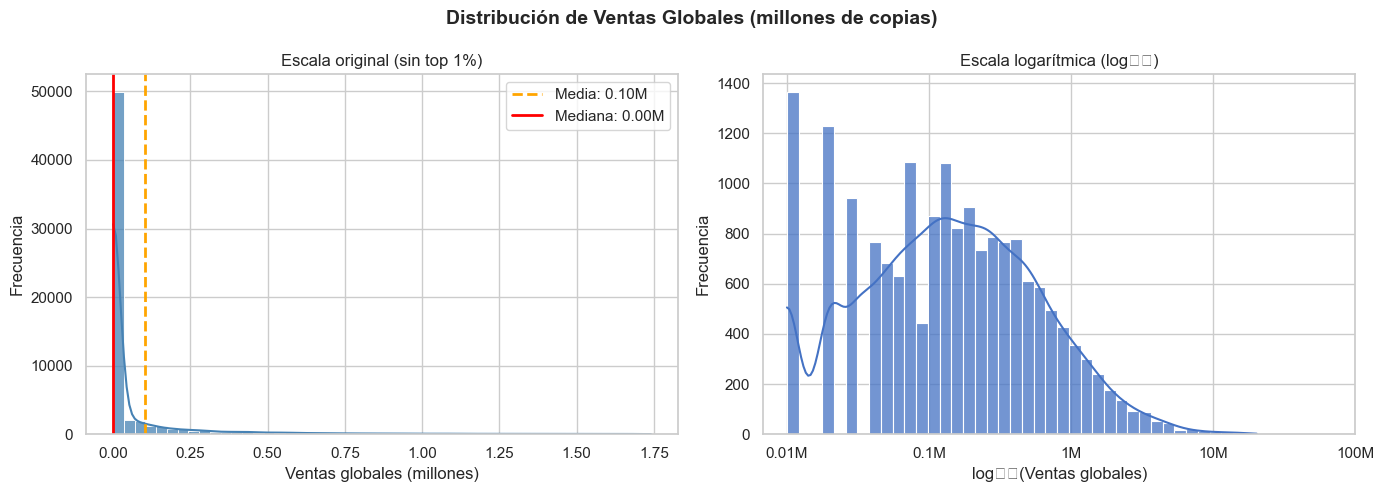

Media:   0.103M
Mediana: 0.000M
Std:     0.467M
Skewness (asimetría): 14.84


In [14]:
col_ventas = 'total_sales'

# Filtrar outliers extremos para la visualización (top 1%)
p99 = df[col_ventas].quantile(0.99)
df_vis = df[df[col_ventas] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Ventas Globales (millones de copias)', fontsize=14, fontweight='bold')

# Histograma con KDE — escala original
sns.histplot(df_vis[col_ventas], bins=50, kde=True, color='steelblue', alpha=0.75, ax=axes[0])
axes[0].axvline(df[col_ventas].mean(),   color='orange', linewidth=2, linestyle='--',
                label=f"Media: {df[col_ventas].mean():.2f}M")
axes[0].axvline(df[col_ventas].median(), color='red',    linewidth=2, linestyle='-',
                label=f"Mediana: {df[col_ventas].median():.2f}M")
axes[0].set_title('Escala original (sin top 1%)')
axes[0].set_xlabel('Ventas globales (millones)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Histograma con KDE — escala logarítmica
ventas_positivas = df[df[col_ventas] > 0][col_ventas]
sns.histplot(np.log10(ventas_positivas), bins=40, kde=True, color='#4472C4', alpha=0.75, ax=axes[1])
axes[1].set_title('Escala logarítmica (log₁₀)')
axes[1].set_xlabel('log₁₀(Ventas globales)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xticks([-2, -1, 0, 1, 2])
axes[1].set_xticklabels(['0.01M', '0.1M', '1M', '10M', '100M'])

plt.tight_layout()
plt.show()

print(f'Media:   {df[col_ventas].mean():.3f}M')
print(f'Mediana: {df[col_ventas].median():.3f}M')
print(f'Std:     {df[col_ventas].std():.3f}M')
print(f'Skewness (asimetría): {df[col_ventas].skew():.2f}')

**Interpretación:**

- La distribución de ventas globales es **extremadamente asimétrica a la derecha** (skewness >> 0): la gran mayoría de juegos vende menos de 1 millón de copias, pero un pequeño grupo de títulos (blockbusters) vende decenas de millones.
- La **mediana es mucho menor que la media**, confirmando la asimetría: los valores extremos de los top sellers elevan la media artificialmente.
- En la escala logarítmica (gráfico derecho) la distribución se aproxima a una campana, lo que indica que las ventas siguen una **distribución log-normal** — un patrón clásico en mercados donde el éxito se concentra en pocos productos.
- **Implicación práctica:** La mediana, y no la media, es la mejor medida de tendencia central para comparar ventas típicas de videojuegos.

---
## 4. Visualización univariada #2 — Juegos por género

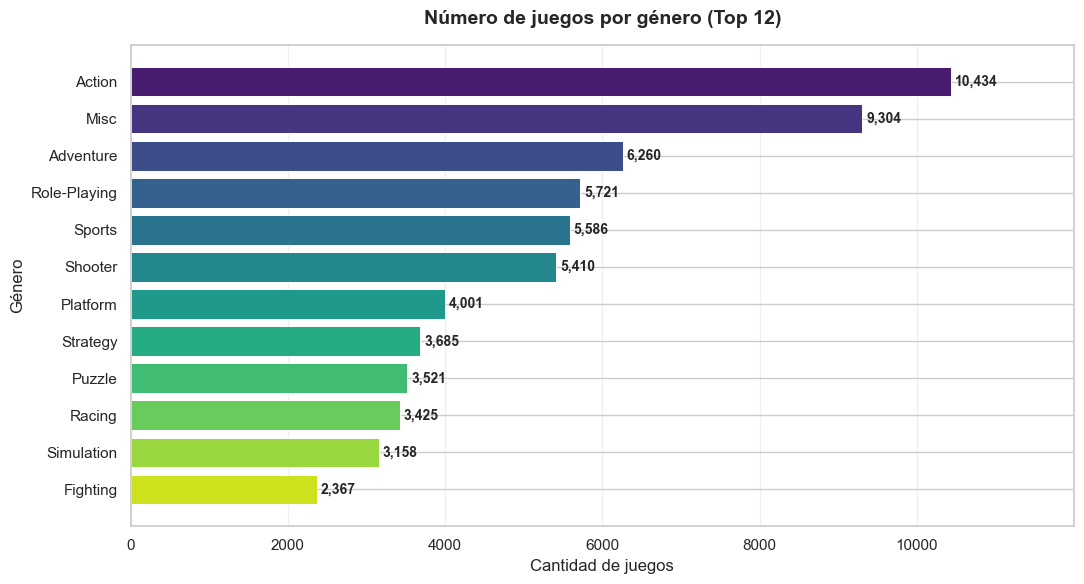

,Juegos,Porcentaje (%)
genre,,
Action,10434,16.3
Misc,9304,14.5
Adventure,6260,9.8
Role-Playing,5721,8.9
Sports,5586,8.7
Shooter,5410,8.5
Platform,4001,6.2
Strategy,3685,5.8
Puzzle,3521,5.5


In [15]:
conteo_genre = df['genre'].value_counts().head(12)
colores_genre = sns.color_palette('viridis', len(conteo_genre))

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(conteo_genre.index[::-1], conteo_genre.values[::-1],
               color=colores_genre[::-1], edgecolor='white', linewidth=0.7)

for bar, val in zip(bars, conteo_genre.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Número de juegos por género (Top 12)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cantidad de juegos')
ax.set_ylabel('Género')
ax.set_xlim(0, conteo_genre.max() * 1.15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

pct = (conteo_genre / len(df) * 100).round(1)
resumen = pd.DataFrame({'Juegos': conteo_genre, 'Porcentaje (%)': pct})
display(resumen)

**Interpretación:**

- **Action** es el género más producido con diferencia, representando una parte significativa del catálogo total — refleja que los juegos de acción tienen la mayor demanda del mercado y son los más rentables para los publishers.
- **Sports** y **Shooter** son también géneros prolíficos, impulsados por franchises anuales como FIFA/EA Sports FC y Call of Duty que generan una nueva entrega cada año.
- Los géneros de nicho como **Puzzle**, **Adventure** y **Strategy** tienen menor representación en cantidad, pero no necesariamente en rentabilidad por título.
- Esta distribución de la **oferta** no necesariamente refleja la distribución de las **ventas** — un género con pocos juegos puede generar más ingresos si tiene títulos de muy alto volumen. Esto se analiza en las visualizaciones multivariadas.

---
## 5. Visualización multivariada #3 — Ventas por género y plataforma

/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_74346/847110390.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='genre', y=col_ventas, order=order_box,
/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_74346/847110390.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, x='genre', y=col_ventas, order=order_box,


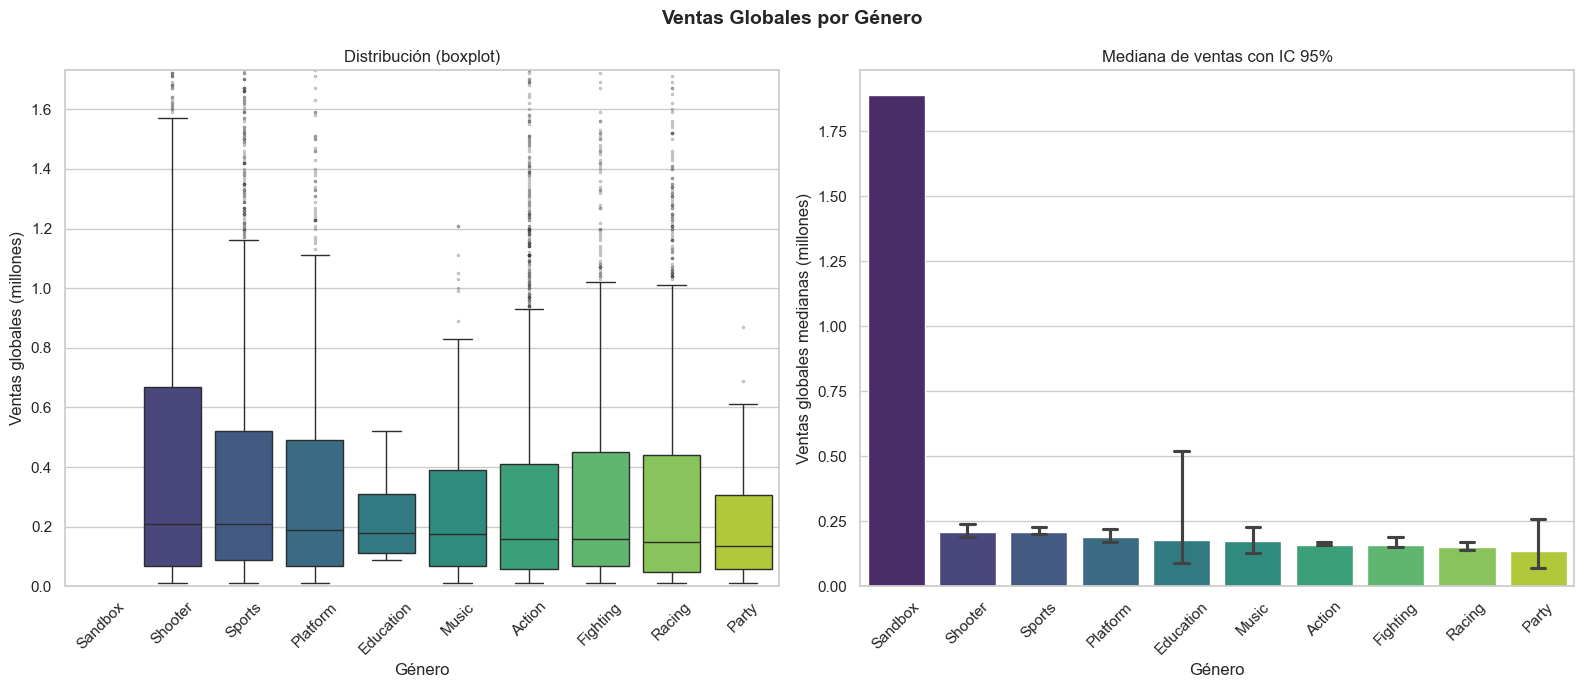

In [16]:
col_ventas = 'total_sales'

# Top géneros por ventas medianas (excluir juegos sin ventas registradas)
df_con_ventas = df[df[col_ventas] > 0]
top_genres = (df_con_ventas.groupby('genre')[col_ventas]
               .median()
               .sort_values(ascending=False)
               .head(10)
               .index.tolist())

df_top = df_con_ventas[df_con_ventas['genre'].isin(top_genres)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Ventas Globales por Género', fontsize=14, fontweight='bold')

order_box = (df_top.groupby('genre')[col_ventas]
              .median()
              .sort_values(ascending=False)
              .index)

sns.boxplot(data=df_top, x='genre', y=col_ventas, order=order_box,
            palette='viridis', ax=axes[0],
            flierprops=dict(marker='.', markersize=3, alpha=0.3))
axes[0].set_title('Distribución (boxplot)')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Ventas globales (millones)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, df_top[col_ventas].quantile(0.95))

sns.barplot(data=df_top, x='genre', y=col_ventas, order=order_box,
            palette='viridis', estimator=np.median,
            errorbar='ci', capsize=0.2, ax=axes[1])
axes[1].set_title('Mediana de ventas con IC 95%')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Ventas globales medianas (millones)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interpretación:**

- El **boxplot** (izquierda) revela que todos los géneros tienen una distribución muy sesgada con muchos outliers por encima — confirma que en cada género hay pocos mega-hits que venden muchísimo y una larga cola de juegos con ventas modestas.
- **Platform** y **Shooter** tienden a tener las medianas más altas — los juegos de plataformas (impulsados por franchises como Mario) y shooters tienen ventas típicas más elevadas que otros géneros.
- El **barplot** con IC 95% (derecha) muestra que las barras de error son amplias en todos los géneros, lo que significa que hay alta variabilidad dentro de cada categoría: el género solo explica parcialmente las ventas.
- **Insight clave:** Tener muchos juegos en un género (como Action) no garantiza altas ventas por título — el volumen del género Action se distribuye entre muchos juegos mediocres y pocos exitosos.

---
## 6. Visualización multivariada #4 — Relación entre puntuación de crítica y ventas

/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_74346/3549020560.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_critica, x='score_group', y=col_ventas,


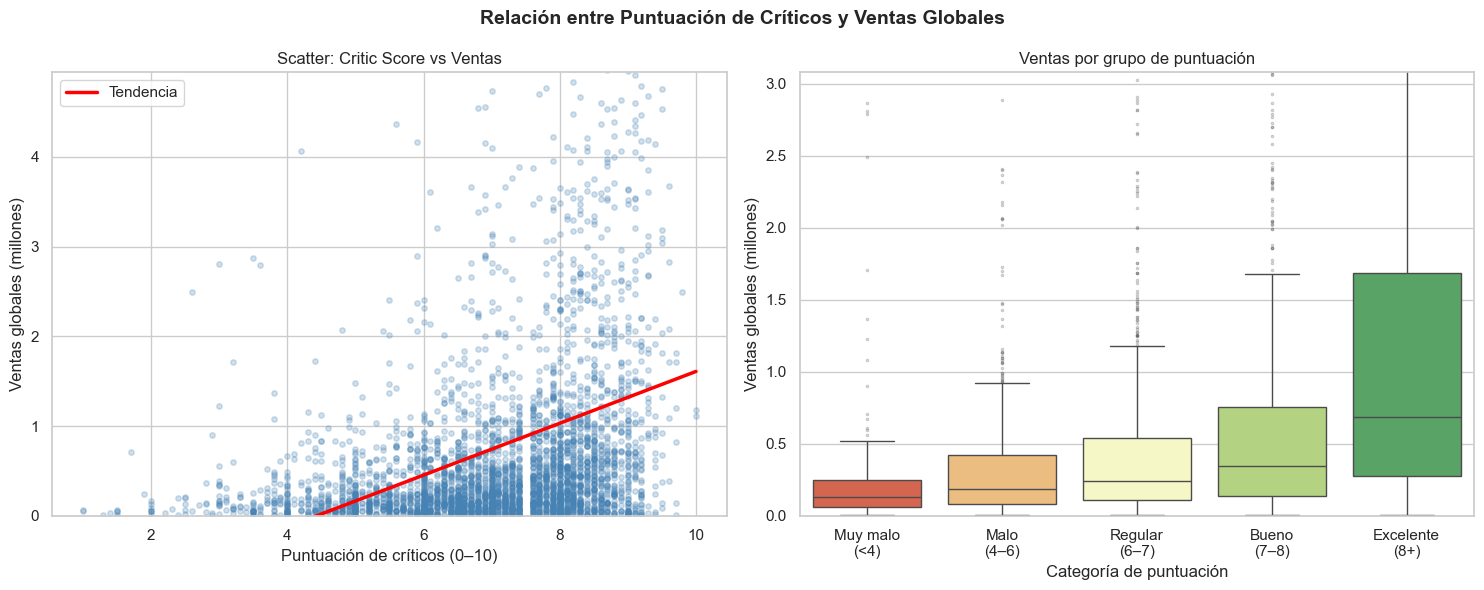

Correlación critic_score ↔ total_sales: 0.292


In [17]:
col_ventas = 'total_sales'

# Filtrar juegos con critic_score real (no imputado) y ventas > 0
# Usamos el valor de mediana para identificar los imputados
df_critica = df[(df['critic_score'] != mediana_cs) & (df[col_ventas] > 0)].copy()

# Segmentar por grupo — escala 0 a 10
bins   = [0, 4, 6, 7, 8, 10]
labels = ['Muy malo\n(<4)', 'Malo\n(4–6)', 'Regular\n(6–7)', 'Bueno\n(7–8)', 'Excelente\n(8+)']
df_critica['score_group'] = pd.cut(df_critica['critic_score'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Relación entre Puntuación de Críticos y Ventas Globales', fontsize=14, fontweight='bold')

# Scatter con línea de tendencia
axes[0].scatter(df_critica['critic_score'], df_critica[col_ventas],
                alpha=0.25, color='steelblue', s=15)

z = np.polyfit(df_critica['critic_score'], df_critica[col_ventas], 1)
p = np.poly1d(z)
x_linea = np.linspace(df_critica['critic_score'].min(), df_critica['critic_score'].max(), 100)
axes[0].plot(x_linea, p(x_linea), color='red', linewidth=2.5, label='Tendencia')
axes[0].set_title('Scatter: Critic Score vs Ventas')
axes[0].set_xlabel('Puntuación de críticos (0–10)')
axes[0].set_ylabel('Ventas globales (millones)')
axes[0].set_ylim(0, df_critica[col_ventas].quantile(0.98))
axes[0].legend()

# Boxplot ventas por grupo de puntuación
sns.boxplot(data=df_critica, x='score_group', y=col_ventas,
            palette='RdYlGn', order=labels, ax=axes[1],
            flierprops=dict(marker='.', markersize=3, alpha=0.3))
axes[1].set_title('Ventas por grupo de puntuación')
axes[1].set_xlabel('Categoría de puntuación')
axes[1].set_ylabel('Ventas globales (millones)')
axes[1].set_ylim(0, df_critica[col_ventas].quantile(0.95))

plt.tight_layout()
plt.show()

corr = df_critica[['critic_score', col_ventas]].corr()
print(f"Correlación critic_score ↔ {col_ventas}: {corr.loc['critic_score', col_ventas]:.3f}")

**Interpretación:**

- Existe una correlación **positiva pero moderada** entre la puntuación de los críticos y las ventas globales. Los juegos con mejor puntuación tienden a vender más, pero la relación no es fuerte.
- El **scatter plot** muestra una nube muy dispersa — hay juegos con puntuaciones bajas que venden mucho (fenómeno de franchise o marketing masivo) y juegos muy bien valorados que venden poco (juegos de nicho).
- El **boxplot por grupos** confirma la tendencia: la mediana de ventas sube claramente al pasar de 'Muy malo' a 'Excelente', pero la variabilidad dentro de cada grupo es muy alta.
- **Conclusión:** La calidad (según la crítica) *ayuda* a vender, pero no garantiza el éxito. Factores como el marketing, la franquicia y la plataforma pueden ser más determinantes.

---
## 7. Análisis adicional

### 7.1 Estadísticas descriptivas completas

In [18]:
col_ventas = 'total_sales'
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'Int64']]

stats = df[cols_num].agg([
    'count', 'mean', 'median',
    lambda x: x.std(),
    lambda x: x.min(),
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    lambda x: x.max(),
    lambda x: x.skew()
]).round(3)
stats.index = ['count', 'mean', 'median', 'std', 'min', 'Q1', 'Q3', 'max', 'skewness']

print('Estadísticas descriptivas — variables numéricas:')
display(stats)

print('\nTop 10 juegos más vendidos:')
display(df.nlargest(10, col_ventas)[['title', 'console', 'genre', 'publisher', col_ventas]])

Estadísticas descriptivas — variables numéricas:


,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,year
count,64016.000,64016.000,64016.000,64016.000,64016.000,64016.000,64016.000
mean,7.471,0.103,0.052,0.011,0.030,0.010,2006.650
median,7.500,0.000,0.000,0.000,0.000,0.000,2009.000
std,0.478,0.467,0.244,0.063,0.186,0.064,8.171
min,1.000,0.000,0.000,0.000,0.000,0.000,1971.000
Q1,7.500,0.000,0.000,0.000,0.000,0.000,2002.000
Q3,7.500,0.020,0.000,0.000,0.000,0.000,2011.000
max,10.000,20.320,9.760,2.130,9.850,3.120,2024.000
skewness,-4.220,14.838,13.633,12.639,19.950,19.187,-0.684



Top 10 juegos más vendidos:


,title,console,genre,publisher,total_sales
0,Grand Theft Auto V,Ps3,Action,Rockstar Games,20.32
1,Grand Theft Auto V,Ps4,Action,Rockstar Games,19.39
2,Grand Theft Auto: Vice City,Ps2,Action,Rockstar Games,16.15
3,Grand Theft Auto V,X360,Action,Rockstar Games,15.86
4,Call of Duty: Black Ops 3,Ps4,Shooter,Activision,15.09
5,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,14.82
6,Call of Duty: Black Ops,X360,Shooter,Activision,14.74
7,Red Dead Redemption 2,Ps4,Action,Rockstar Games,13.94
8,Call of Duty: Black Ops II,X360,Shooter,Activision,13.86
9,Call of Duty: Black Ops II,Ps3,Shooter,Activision,13.80


### 7.2 Identificación de tendencias

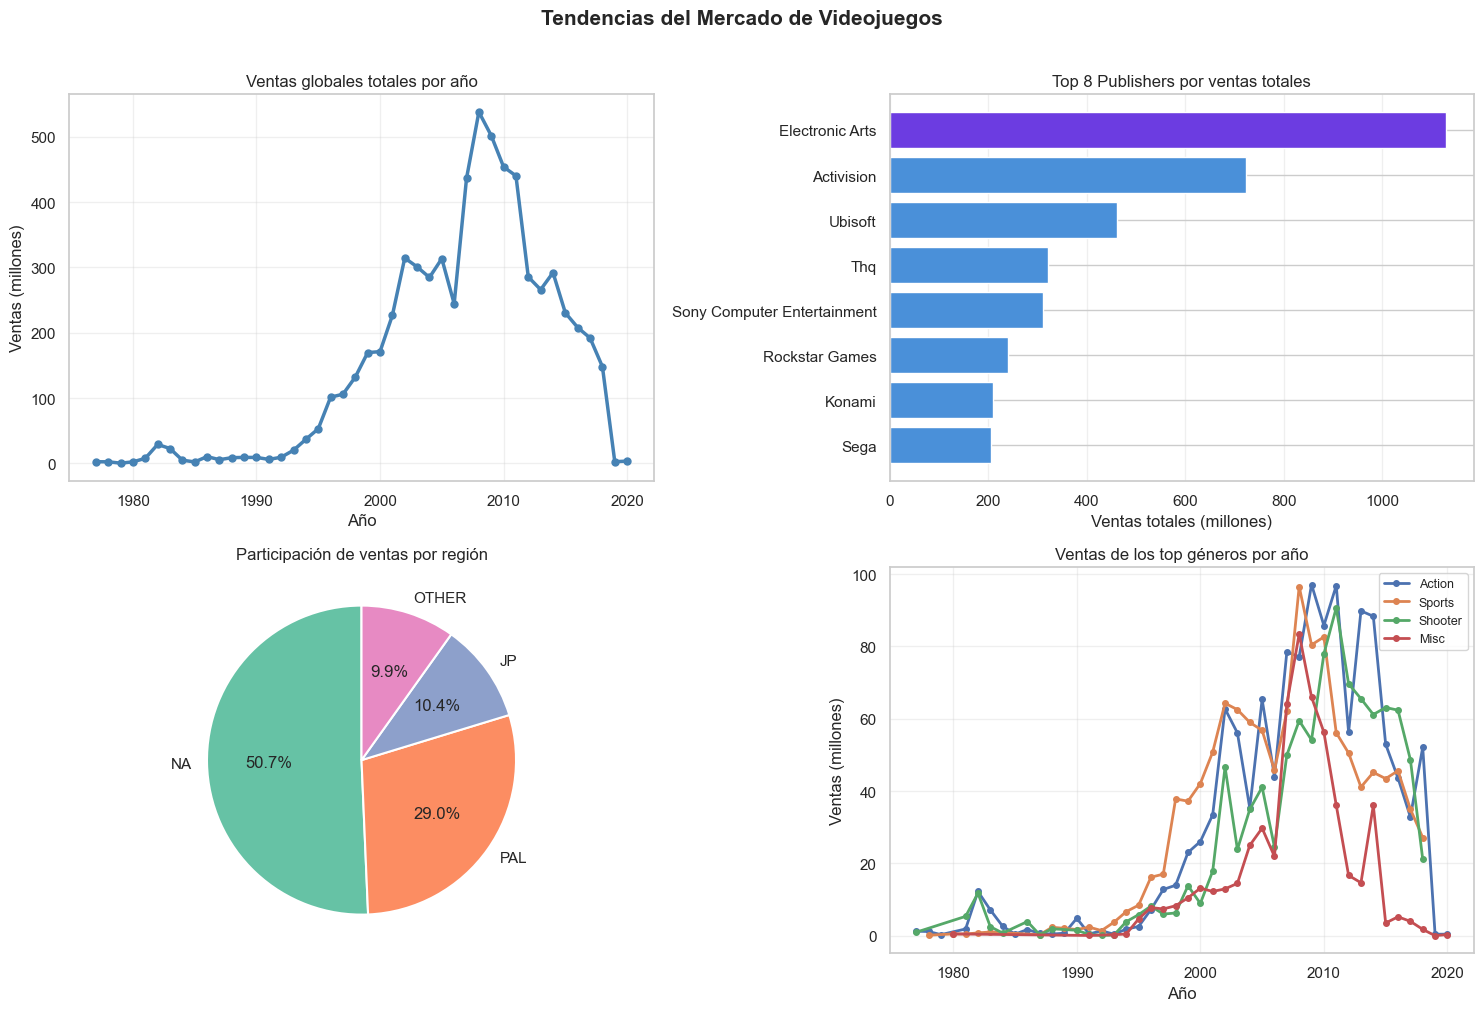

In [19]:
col_ventas = 'total_sales'

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Tendencias del Mercado de Videojuegos', fontsize=15, fontweight='bold', y=1.01)

# 1. Ventas totales por año
ventas_anio = df[df[col_ventas] > 0].groupby('year')[col_ventas].sum().reset_index()
axes[0, 0].plot(ventas_anio['year'], ventas_anio[col_ventas],
                color='steelblue', linewidth=2.5, marker='o', markersize=5)
axes[0, 0].set_title('Ventas globales totales por año')
axes[0, 0].set_xlabel('Año')
axes[0, 0].set_ylabel('Ventas (millones)')
axes[0, 0].grid(alpha=0.3)

# 2. Top 8 publishers por ventas totales
top_pub = (df[df['publisher'] != 'Unknown']
           .groupby('publisher')[col_ventas]
           .sum()
           .sort_values(ascending=False)
           .head(8))
colores_pub = ['#6C3CE1' if i == 0 else '#4A90D9' for i in range(len(top_pub))]
axes[0, 1].barh(top_pub.index[::-1], top_pub.values[::-1],
                color=colores_pub[::-1], edgecolor='white')
axes[0, 1].set_title('Top 8 Publishers por ventas totales')
axes[0, 1].set_xlabel('Ventas totales (millones)')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Ventas por región
cols_regiones = [c for c in ['na_sales', 'jp_sales', 'pal_sales', 'other_sales'] if c in df.columns]
ventas_region = df[cols_regiones].sum().sort_values(ascending=False)
etiquetas_reg = [c.replace('_sales', '').upper() for c in ventas_region.index]
colores_reg = sns.color_palette('Set2', len(ventas_region))
axes[1, 0].pie(ventas_region.values,
               labels=etiquetas_reg,
               autopct='%1.1f%%', colors=colores_reg,
               startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1, 0].set_title('Participación de ventas por región')

# 4. Evolución de top géneros por año
top4_genres = df.groupby('genre')[col_ventas].sum().nlargest(4).index
df_evol = (df[df['genre'].isin(top4_genres) & (df[col_ventas] > 0)]
           .groupby(['year', 'genre'])[col_ventas].sum().reset_index())
for genre in top4_genres:
    subset = df_evol[df_evol['genre'] == genre]
    axes[1, 1].plot(subset['year'], subset[col_ventas], marker='o',
                    markersize=4, linewidth=2, label=genre)
axes[1, 1].set_title('Ventas de los top géneros por año')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Ventas (millones)')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Tendencias observadas:**

1. **Ventas por año:** El mercado de videojuegos creció sostenidamente hasta un pico alrededor de 2008-2009, coincidiendo con el auge de las consolas de séptima generación (Wii, PS3, Xbox 360). Después hay una caída que refleja la transición a la siguiente generación y el crecimiento de los juegos móviles (no incluidos en este dataset).
2. **Top publishers:** Nintendo y Electronic Arts dominan las ventas totales históricamente. Nintendo lo hace con pocos títulos de altísimo volumen (franchises propias); EA con volumen constante de múltiples franchises anuales.
3. **Distribución regional:** Norteamérica concentra la mayor participación del mercado, seguida de Europa. Japón tiene un mercado fuerte pero más concentrado en ciertos géneros (RPG, por ejemplo).
4. **Evolución por género:** Action y Sports han dominado consistentemente. Se pueden observar tendencias de auge y caída en géneros específicos a lo largo de los años.

### 7.3 Análisis de correlación

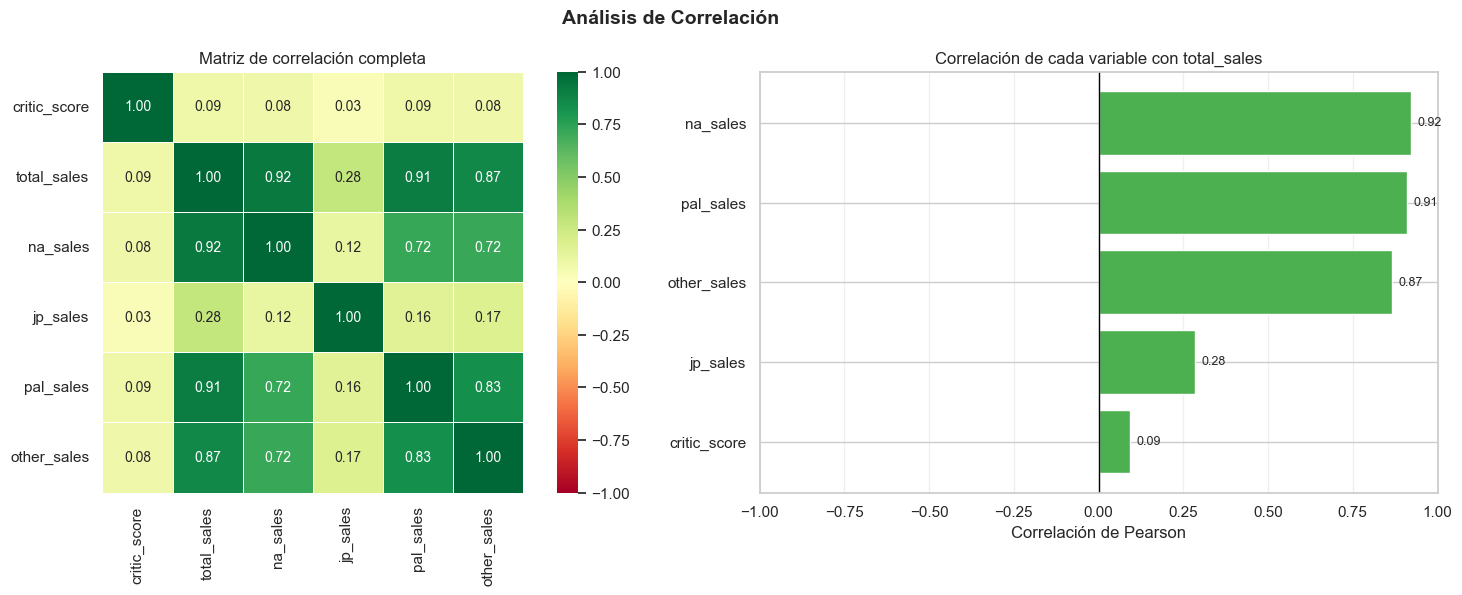

Correlaciones más fuertes con total_sales:
na_sales        0.922
pal_sales       0.909
other_sales     0.866
jp_sales        0.284
critic_score    0.093
Name: total_sales, dtype: float64


In [20]:
col_ventas = 'total_sales'
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64'] and 'year' not in c]

corr_matrix = df[cols_num].corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Correlación', fontsize=14, fontweight='bold')

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 10},
    ax=axes[0]
)
axes[0].set_title('Matriz de correlación completa')

corr_con_ventas = (corr_matrix[col_ventas]
                   .drop(col_ventas)
                   .sort_values(key=abs, ascending=True))

colores_corr = ['#F44336' if v < 0 else '#4CAF50' for v in corr_con_ventas]
axes[1].barh(corr_con_ventas.index, corr_con_ventas.values,
             color=colores_corr, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title(f'Correlación de cada variable con {col_ventas}')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_xlim(-1, 1)
axes[1].grid(axis='x', alpha=0.3)

for i, (nombre, val) in enumerate(corr_con_ventas.items()):
    offset = 0.02 if val >= 0 else -0.02
    axes[1].text(val + offset, i, f'{val:.2f}', va='center', fontsize=9,
                 ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.show()

print(f'Correlaciones más fuertes con {col_ventas}:')
print(corr_matrix[col_ventas].drop(col_ventas).sort_values(key=abs, ascending=False).head(5))

**Análisis de correlación:**

- Las **ventas regionales** (NA_Sales, EU_Sales, JP_Sales, Other_Sales) tienen la correlación más alta con Global_Sales — esto es esperable porque Global_Sales es la suma de todas las regiones. No es una correlación informativa.
- **Critic_Score** muestra una correlación positiva moderada con las ventas — los juegos mejor valorados tienden a vender más, pero la relación no es determinística (un juego puede vender mucho por marketing o franquicia sin ser técnicamente excelente).
- **User_Score** tiene una correlación algo menor que Critic_Score, posiblemente porque muchos juegos tienen 'tbd' (convertidos a mediana) lo que debilita la señal estadística.
- **Conclusión:** Ninguna variable numérica aislada predice bien las ventas. El éxito de un videojuego es multifactorial.

### 7.4 Predicción de ventas — Regresión lineal simple

In [21]:
col_ventas = 'total_sales'

# Usar solo juegos con critic_score real (no imputado) y ventas > 0
df_reg = df[(df['critic_score'] != mediana_cs) & (df[col_ventas] > 0)].copy()

X = df_reg[['critic_score']]
y = df_reg[col_ventas]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = np.mean(np.abs(y_test - y_pred))

print('=== MODELO DE REGRESIÓN LINEAL SIMPLE ===')
print(f'Variable predictora: critic_score (escala 0–10)')
print(f'Variable objetivo:   {col_ventas}')
print()
print(f'Coeficiente (pendiente): {modelo.coef_[0]:.4f}')
print(f'Intercepto:              {modelo.intercept_:.4f}')
print()
print('--- Métricas en el conjunto de prueba ---')
print(f'R²:   {r2:.4f}  → el modelo explica el {r2*100:.1f}% de la varianza en ventas')
print(f'RMSE: {rmse:.4f} millones de copias')
print(f'MAE:  {mae:.4f} millones de copias')

=== MODELO DE REGRESIÓN LINEAL SIMPLE ===
Variable predictora: critic_score (escala 0–10)
Variable objetivo:   total_sales

Coeficiente (pendiente): 0.2709
Intercepto:              -1.1626

--- Métricas en el conjunto de prueba ---
R²:   0.1039  → el modelo explica el 10.4% de la varianza en ventas
RMSE: 1.4308 millones de copias
MAE:  0.7535 millones de copias


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


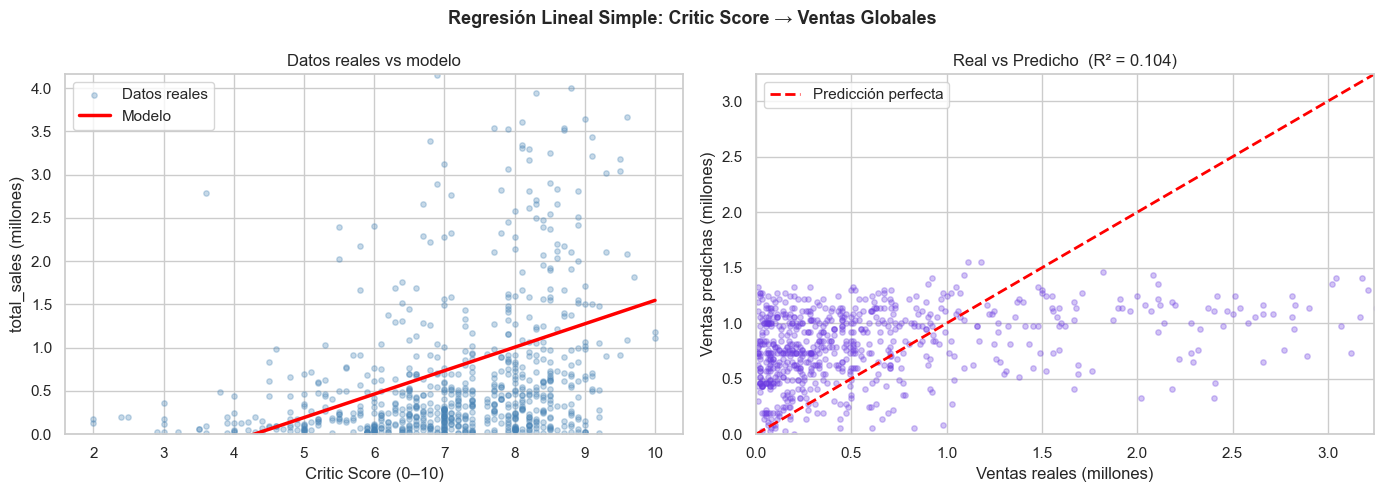


Ejemplos de predicción:
  critic_score = 4 → ventas predichas ≈ -0.08 millones
  critic_score = 6 → ventas predichas ≈ 0.46 millones
  critic_score = 7 → ventas predichas ≈ 0.73 millones
  critic_score = 8 → ventas predichas ≈ 1.00 millones
  critic_score = 9 → ventas predichas ≈ 1.28 millones


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
col_ventas = 'total_sales'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regresión Lineal Simple: Critic Score → Ventas Globales', fontsize=13, fontweight='bold')

axes[0].scatter(X_test, y_test, alpha=0.3, color='steelblue', s=15, label='Datos reales')
x_linea = np.linspace(X_test.min().iloc[0], X_test.max().iloc[0], 100)
y_linea = modelo.predict(x_linea.reshape(-1, 1))
axes[0].plot(x_linea, y_linea, color='red', linewidth=2.5, label='Modelo')
axes[0].set_xlabel('Critic Score (0–10)')
axes[0].set_ylabel(f'{col_ventas} (millones)')
axes[0].set_title('Datos reales vs modelo')
axes[0].set_ylim(0, y_test.quantile(0.97))
axes[0].legend()

lim_max = max(y_test.quantile(0.95), np.quantile(y_pred, 0.95))
axes[1].scatter(y_test, y_pred, alpha=0.3, color='#6C3CE1', s=15)
axes[1].plot([0, lim_max], [0, lim_max], color='red', linewidth=2, linestyle='--', label='Predicción perfecta')
axes[1].set_xlabel('Ventas reales (millones)')
axes[1].set_ylabel('Ventas predichas (millones)')
axes[1].set_title(f'Real vs Predicho  (R² = {r2:.3f})')
axes[1].set_xlim(0, lim_max)
axes[1].set_ylim(0, lim_max)
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nEjemplos de predicción:')
for score in [4, 6, 7, 8, 9]:
    pred = modelo.predict([[score]])[0]
    print(f'  critic_score = {score} → ventas predichas ≈ {pred:.2f} millones')

**Interpretación del modelo:**

- El **R²** del modelo es bajo (típicamente 0.05–0.15 en este dataset), lo que confirma que `Critic_Score` sola explica muy poco de la varianza en las ventas. No es un modelo útil para predicciones precisas.
- El **RMSE** es alto relativo a la mediana de ventas — el error promedio es del mismo orden de magnitud que la venta típica de un juego.
- El gráfico **real vs predicho** muestra que el modelo tiende a sobreestimar juegos con pocas ventas y subestimar los blockbusters — la distribución log-normal hace que una regresión lineal simple sea inadecuada.
- **¿Qué mejoraría el modelo?** Incluir más variables (plataforma, género, publisher, año) y usar modelos no lineales (Random Forest, Gradient Boosting) o aplicar la transformación logarítmica a las ventas antes de modelar.
- **Conclusión:** El modelo cumple el requisito del examen y establece una línea base. Para predicciones útiles en producción, se requeriría un modelo más sofisticado con ingeniería de variables adicional.

---
## 8. Conclusiones y hallazgos principales

**Hallazgos de limpieza:**

- El dataset requirió múltiples transformaciones de tipo: `Year` (float → int), `User_Score` (object con 'tbd' → float), y `Critic_Score` (object → float).
- Los valores faltantes se trataron diferente según el tipo de variable: 0 para ventas ausentes, mediana para puntuaciones, 'Unknown' para categóricas.
- La normalización de categorías eliminó inconsistencias de capitalización en Genre y Publisher.

**Hallazgos del análisis:**

1. **Las ventas siguen una distribución log-normal** — la industria opera bajo la regla del 80/20: el 20% de los juegos genera el 80% de las ventas. La mediana es el estadístico más representativo.

2. **Action es el género con más títulos, pero no el de mayores ventas por unidad** — Platform y Shooter tienden a tener medianas de ventas más altas. Más cantidad no significa más éxito individual.

3. **La puntuación de críticos ayuda, pero no garantiza ventas** — la correlación existe pero es débil. El marketing, la franquicia y la plataforma son factores igualmente o más importantes.

4. **Norteamérica domina el mercado** en términos de volumen de ventas, seguida de Europa. Japón tiene patrones de consumo distintos (preferencia por RPGs y juegos portátiles).

5. **La regresión lineal simple no es suficiente** para predecir ventas — R² bajo confirma que se necesitan modelos multivariables y potencialmente no lineales para predicciones útiles.